In [8]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [17]:
print("X", X.shape)
print("y", y.shape)

X (100, 5)
y (100,)


In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-2.528084,-2.718286,1.084135,-0.504760,-0.300414,0
1,-0.233971,-2.043954,-2.206285,-2.626862,-1.973055,1
2,-2.434733,-1.688281,-0.193893,0.165470,0.547958,0
3,-0.867883,-0.172933,-1.060325,-0.410599,0.042158,0
4,-0.375112,-1.453916,-1.844444,-1.421142,-0.314818,0


In [18]:
# function for row sampling

def sample_rows(df, percent):
  return df.sample(int(percent*df.shape[0]), replace=True)

sample_rows(df, 0.1)

,col1,col2,col3,col4,col5,target
19,1.613075,-1.276608,-0.194741,-0.295701,-1.614867,1
31,0.578192,-0.407523,-0.151107,1.001680,1.417179,1
9,-0.765272,1.309198,-2.707631,-2.406958,-0.573219,1
93,1.228741,0.594112,-0.601683,-0.409416,-0.367278,1
40,1.956355,-0.103570,-0.866223,-0.860735,-0.385948,1
63,-1.582836,-1.098976,-0.138889,-0.269845,-0.838842,0
14,0.037063,0.028965,-0.890121,0.008383,0.683973,1
47,0.939385,-2.346942,-1.724677,-3.059431,-1.883634,0
54,0.989369,-2.267934,-0.509536,-1.967131,-2.698148,0
93,1.228741,0.594112,-0.601683,-0.409416,-0.367278,1


In [29]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

sample_features(df, 0.8)

,col4,col3,col1,col5,target
0,-0.504760,1.084135,-2.528084,-0.300414,0
1,-2.626862,-2.206285,-0.233971,-1.973055,1
2,0.165470,-0.193893,-2.434733,0.547958,0
3,-0.410599,-1.060325,-0.867883,0.042158,0
4,-1.421142,-1.844444,-0.375112,-0.314818,0
...,...,...,...,...,...
95,0.394391,2.385123,-0.557256,1.551986,0
96,-1.102260,-2.498186,-2.275896,-0.764680,0
97,-1.345196,-1.842725,0.254631,0.921460,1
98,-1.076926,-1.160399,1.309386,-0.180410,1


In [37]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

combined_sampling(df, 0.1, 0.8)

,col2,col3,col1,col4,target
61,-0.244545,-0.921403,-0.477619,-1.249698,0
50,1.001598,-3.049319,-1.134506,-1.040022,0
52,-2.050426,0.931043,-2.781714,-0.292781,0
88,-0.463501,-2.015369,0.637913,-2.412895,0
59,-0.705610,-2.331614,-1.099966,-1.074006,0
98,0.023913,-1.160399,1.309386,-1.076926,1
79,-1.985661,0.537761,3.183143,0.248948,1
90,-0.002525,-2.546763,-0.556808,-1.041001,0
15,-0.087587,-1.823943,-1.675321,-0.167981,0
27,-2.685222,-1.189308,1.484763,-1.730042,1


In [56]:
df1 = sample_rows(df, 0.1)
# df1 = sample_features(df, 0.8)
# df1 = combined_sampling(df, 0.1, 0.8)

In [57]:
df2 = sample_rows(df, 0.1)
# df2 = sample_features(df, 0.8)
# df2 = combined_sampling(df, 0.1, 0.8)

In [58]:
df3 = sample_rows(df, 0.1)
# df3 = sample_features(df, 0.8)
# df3 = combined_sampling(df,0.1, 0.8)

In [59]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='str')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='str')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='str')


In [60]:
from sklearn.tree import DecisionTreeClassifier

clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [97]:
clf1.fit(df1.iloc[:, 0:7], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:7], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:7], df3.iloc[:, -1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [98]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[2] <= -1.771\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.625, 0.5, '  False')]

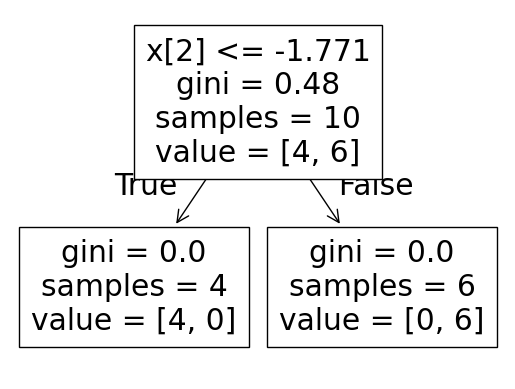

In [99]:
plot_tree(clf1)

[Text(0.6666666666666666, 0.9166666666666666, 'x[1] <= -0.515\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.5, 0.75, 'x[1] <= -0.867\ngini = 0.444\nsamples = 6\nvalue = [2, 4]'),
 Text(0.5833333333333333, 0.8333333333333333, 'True  '),
 Text(0.3333333333333333, 0.5833333333333334, 'x[1] <= -2.154\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.16666666666666666, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.5, 0.4166666666666667, 'x[1] <= -1.84\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.3333333333333333, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6666666666666666, 0.25, 'x[1] <= -1.22\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.5, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8333333333333334, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6666666666666666, 0.5833333333333334, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8333333333333334, 0.75, 'gini = 0.0

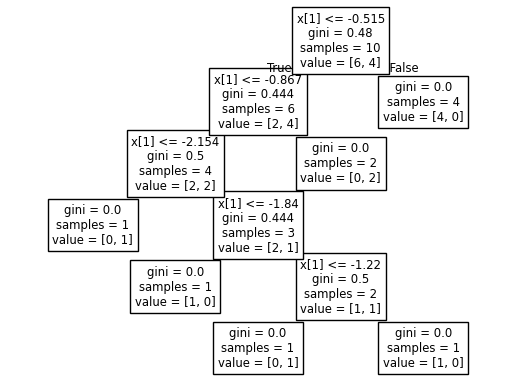

In [64]:
plot_tree(clf2)

[Text(0.4, 0.875, 'x[0] <= -0.946\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[0] <= -0.129\ngini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[0] <= -0.568\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]')]

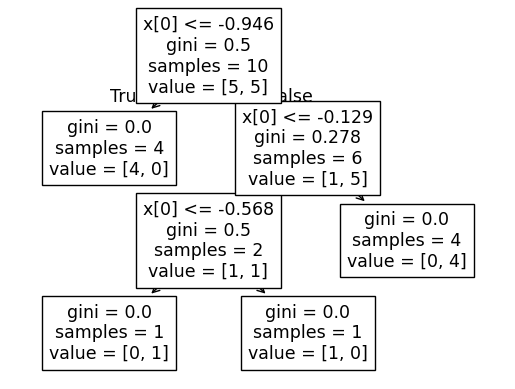

In [65]:
plot_tree(clf3)

In [66]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/Users/kevin/Desktop/ai-engineer/machine-learning/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [67]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/Users/kevin/Desktop/ai-engineer/machine-learning/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [68]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/Users/kevin/Desktop/ai-engineer/machine-learning/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [96]:
df.sample(14,replace=False)

,col1,col2,col3,col4,col5,target
70,-2.436402,-1.207004,-1.339649,-0.512012,-1.688449,0
93,1.228741,0.594112,-0.601683,-0.409416,-0.367278,1
66,-0.624433,0.988618,-2.602738,-2.095320,0.187039,1
68,-1.815830,0.460751,-0.620509,0.221558,0.691554,0
65,-1.879199,0.117509,-3.370164,-0.549842,-1.793028,0
90,-0.556808,-0.002525,-2.546763,-1.041001,-2.069681,0
76,0.973899,-2.049043,-0.685926,-1.219442,-2.412665,1
55,-0.903941,-0.444066,-1.729846,-1.394532,-1.889327,0
59,-1.099966,-0.705610,-2.331614,-1.074006,-0.879872,0
83,-3.480815,-1.141392,0.405458,1.516122,1.203990,0
